#Import Library

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
sns.set()
%matplotlib inline
sns.set()
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics.pairwise import cosine_similarity
import missingno as msno
from sklearn.metrics import silhouette_score
from sklearn.metrics import pairwise_distances
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN

#Read Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df_vif_clean = pd.read_excel(
    '/content/drive/MyDrive/df_vif_clean.xlsx'
)

df_vif_clean.head()

,flight distance,food and drink,on-board service,leg room service,checkin service,arrival delay in minutes,avg digital score,class,gender_Male,customer type_Loyal Customer,type of travel_Personal Travel,satisfaction_Satisfied,travel distance category_Medium,age group_Old,age group_Young,delay category_Low,delay category_Medium
0,460,5,4,3,4,18,3.0,1,1,1,1,0,0,0,1,1,0
1,235,1,1,5,1,6,3.0,2,1,0,0,0,0,0,0,1,0
2,1142,5,4,3,4,0,3.5,2,0,1,0,1,1,0,0,0,0
3,562,2,2,5,1,9,3.5,2,0,1,0,0,0,0,0,1,0
4,214,4,3,4,3,0,4.0,2,1,1,0,1,0,1,0,0,0


In [4]:
# df_vif_clean = pd.read_excel('https://raw.github.com/nadiraaini77/python-data-analyst/master/df_vif_clean.xlsx')

#Scaling

In [5]:
rs = RobustScaler()
x_scaled = pd.DataFrame(rs.fit_transform(df_vif_clean), columns = rs.feature_names_in_)
x_scaled

,flight distance,food and drink,on-board service,leg room service,checkin service,arrival delay in minutes,avg digital score,class,gender_Male,customer type_Loyal Customer,type of travel_Personal Travel,satisfaction_Satisfied,travel distance category_Medium,age group_Old,age group_Young,delay category_Low,delay category_Medium
0,-0.288187,1.0,0.0,-0.5,1.0,1.384615,0.00,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1,-0.457487,-1.0,-1.5,0.5,-2.0,0.461538,0.00,0.5,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.224981,1.0,0.0,-0.5,1.0,0.000000,0.25,0.5,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
3,-0.211437,-0.5,-1.0,0.5,-2.0,0.692308,0.25,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.473288,0.5,-0.5,0.0,0.0,0.000000,0.50,0.5,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103899,-0.489842,-0.5,-0.5,-1.5,-1.0,0.000000,-0.50,-0.5,0.0,-1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
103900,1.131678,-0.5,0.5,0.5,2.0,0.000000,0.50,0.5,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
103901,0.866817,0.5,-0.5,-1.0,2.0,1.076923,-1.00,0.5,1.0,-1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
103902,0.118134,-1.0,0.0,0.5,2.0,0.000000,-1.00,-0.5,0.0,-1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


#PCA

In [6]:
pca = PCA()
pca.fit(x_scaled)
pca.explained_variance_ratio_

array([0.60703419, 0.11699841, 0.05737045, 0.03318457, 0.03062894,
       0.02219295, 0.02051658, 0.01832834, 0.01694655, 0.01648506,
       0.0158102 , 0.01207324, 0.00966491, 0.0077243 , 0.00663172,
       0.00491223, 0.00349736])

Text(0, 0.5, 'Cumulative Explained Variance')

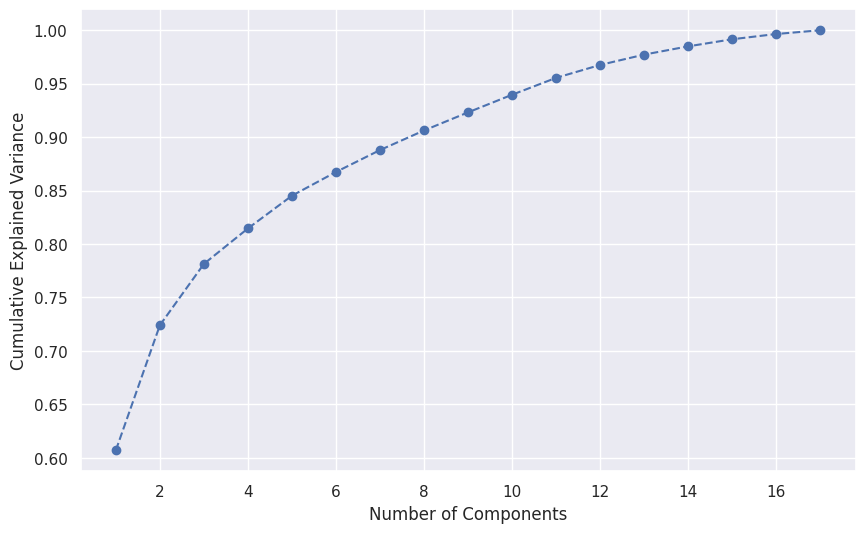

In [7]:
plt.figure(figsize=(10,6))
plt.plot(range(1,18), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--') #18 didapat dari 17 kolom + 1
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

In [8]:
pca = PCA(n_components=4)
pca.fit(x_scaled)
df_pca_components = pd.DataFrame(
    data=pca.components_.round(4),
    columns=x_scaled.columns.values,
    index={'component'+str(i+1): i for i in range(4)})
df_pca_components

,flight distance,food and drink,on-board service,leg room service,checkin service,arrival delay in minutes,avg digital score,class,gender_Male,customer type_Loyal Customer,type of travel_Personal Travel,satisfaction_Satisfied,travel distance category_Medium,age group_Old,age group_Young,delay category_Low,delay category_Medium
component1,-0.0010,-0.0078,-0.0084,0.0022,-0.0113,0.9990,-0.0040,-0.0026,0.0001,-0.0007,-0.0006,-0.0102,-0.0004,-0.0021,0.0011,-0.0227,0.0318
component2,0.1186,0.0774,0.1868,0.1452,0.9355,0.0149,0.1033,0.1080,0.0061,0.0249,-0.0310,0.1495,0.0299,0.0280,-0.0258,-0.0017,-0.0035
component3,0.6051,0.1446,0.2128,0.2864,-0.3133,0.0049,0.2551,0.3343,0.0063,0.0897,-0.2614,0.3141,0.1359,0.0767,-0.1060,0.0038,-0.0039
component4,-0.5303,0.0452,0.5385,0.5984,-0.1424,0.0015,0.0411,-0.0744,0.0215,-0.0579,0.0268,0.1102,-0.1486,-0.0197,0.0247,-0.0382,-0.0018


In [9]:
# plt.figure(figsize=(20,20))
# s = sns.heatmap(df_pca_components,
#     vmin=-1,
#     vmax=1,
#     cmap='RdBu',
#     annot=True)
# plt.title('Correlation Matrix')
# plt.show()

In [10]:
pca_scores = pca.transform(x_scaled)
results = {}
for i in range(1, 5): #5 didapat dari 4 + 1
  kmeans_pca = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans_pca.fit(pca_scores)
  results[i] = kmeans_pca.inertia_

#Elbow Method

In [11]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(pca_scores)

    wcss.append(kmeans.inertia_)

In [12]:
wcss

[1244880.5894717502,
 675466.5927267674,
 558335.9645828329,
 404658.09982377954,
 361420.5364737932,
 293790.7071605268,
 271674.0508593912,
 238992.52816792476,
 214194.83776480806,
 203830.96440501048]

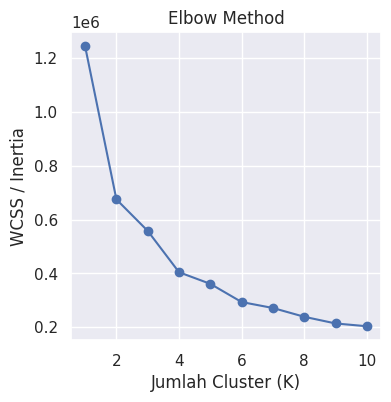

In [13]:
plt.figure(figsize=(4,4))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('WCSS / Inertia')

plt.show()

#K-Means

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

labels_kmeans = kmeans.fit_predict(pca_scores)

In [15]:
kmeans_pca = KMeans(n_clusters=4,random_state=42)
kmeans_pca.fit(pca_scores)

KMeans(n_clusters=4, random_state=42)

In [16]:
df_segm_pca = pd.concat([df_vif_clean.reset_index(drop=True),pd.DataFrame(pca_scores,columns=['component 1','component 2','component 3','component 4'])],axis=1)
df_segm_pca['Cluster'] = kmeans_pca.labels_
df_segm_pca.head()

,flight distance,food and drink,on-board service,leg room service,checkin service,arrival delay in minutes,avg digital score,class,gender_Male,customer type_Loyal Customer,...,travel distance category_Medium,age group_Old,age group_Young,delay category_Low,delay category_Medium,component 1,component 2,component 3,component 4,Cluster
0,460,5,4,3,4,18,3.0,1,1,1,...,0,0,1,1,0,0.183443,0.570088,-0.855860,0.313683,0
1,235,1,1,5,1,6,3.0,2,1,0,...,0,0,0,1,0,-0.675236,-2.474063,0.099699,0.498636,2
2,1142,5,4,3,4,0,3.5,2,0,1,...,1,0,0,0,0,-1.191141,0.921718,0.485957,-0.060518,0
3,562,2,2,5,1,9,3.5,2,0,1,...,0,0,0,1,0,-0.454895,-2.264721,0.575640,0.591289,2
4,214,4,3,4,3,0,4.0,2,1,1,...,0,1,0,0,0,-1.172461,-0.126017,0.352151,0.620137,0


In [17]:
#lihat jumlah anggota cluster
df_segm_pca['Cluster'].value_counts()

,count
Cluster,
0,55789
2,37791
3,8962
1,1362


In [18]:
df_segm_pca['Cluster'].value_counts(normalize=True)*100

,proportion
Cluster,
0,53.692832
2,36.371073
3,8.625269
1,1.310825


In [19]:
#profiling
cluster_profile = (
    df_segm_pca
    .groupby('Cluster')
    .mean(numeric_only=True)
    .round(2)
)

cluster_profile

,flight distance,food and drink,on-board service,leg room service,checkin service,arrival delay in minutes,avg digital score,class,gender_Male,customer type_Loyal Customer,...,satisfaction_Satisfied,travel distance category_Medium,age group_Old,age group_Young,delay category_Low,delay category_Medium,component 1,component 2,component 3,component 4
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1344.36,3.34,3.74,3.62,4.14,5.02,3.21,1.26,0.50,0.84,...,0.60,0.32,0.39,0.16,0.44,0.04,-0.80,0.90,0.03,0.00
1,1218.51,2.98,3.17,3.65,3.28,248.46,2.98,1.00,0.50,0.81,...,0.37,0.30,0.34,0.21,0.00,0.00,17.93,0.23,0.08,0.06
2,969.72,3.02,2.89,2.95,2.09,6.14,2.72,0.69,0.49,0.78,...,0.21,0.25,0.33,0.23,0.45,0.05,-0.68,-1.32,-0.04,-0.01
3,1147.21,3.12,3.27,3.31,3.23,81.83,2.93,0.99,0.49,0.81,...,0.36,0.27,0.35,0.20,0.02,0.66,5.15,-0.03,-0.04,0.00


In [20]:
df_segm_pca.rename(columns={
    "Cluster": "Segment", #ganti nama kolom
}, inplace=True)
df_segm_pca["Segment"].replace({
    0: "Loyal Satisfied Passenger",
    1: "Severely Delayed Passenger",
    2: "Digitally Frustrated Passenger",
    3: "Delay Sensitive Passenger"
}, inplace=True)
df_segm_pca.head()

,flight distance,food and drink,on-board service,leg room service,checkin service,arrival delay in minutes,avg digital score,class,gender_Male,customer type_Loyal Customer,...,travel distance category_Medium,age group_Old,age group_Young,delay category_Low,delay category_Medium,component 1,component 2,component 3,component 4,Segment
0,460,5,4,3,4,18,3.0,1,1,1,...,0,0,1,1,0,0.183443,0.570088,-0.855860,0.313683,Loyal Satisfied Passenger
1,235,1,1,5,1,6,3.0,2,1,0,...,0,0,0,1,0,-0.675236,-2.474063,0.099699,0.498636,Digitally Frustrated Passenger
2,1142,5,4,3,4,0,3.5,2,0,1,...,1,0,0,0,0,-1.191141,0.921718,0.485957,-0.060518,Loyal Satisfied Passenger
3,562,2,2,5,1,9,3.5,2,0,1,...,0,0,0,1,0,-0.454895,-2.264721,0.575640,0.591289,Digitally Frustrated Passenger
4,214,4,3,4,3,0,4.0,2,1,1,...,0,1,0,0,0,-1.172461,-0.126017,0.352151,0.620137,Loyal Satisfied Passenger


In [21]:
#jumlah anggota tiap segment
df_segm_pca['Segment'].value_counts()

,count
Segment,
Loyal Satisfied Passenger,55789
Digitally Frustrated Passenger,37791
Delay Sensitive Passenger,8962
Severely Delayed Passenger,1362


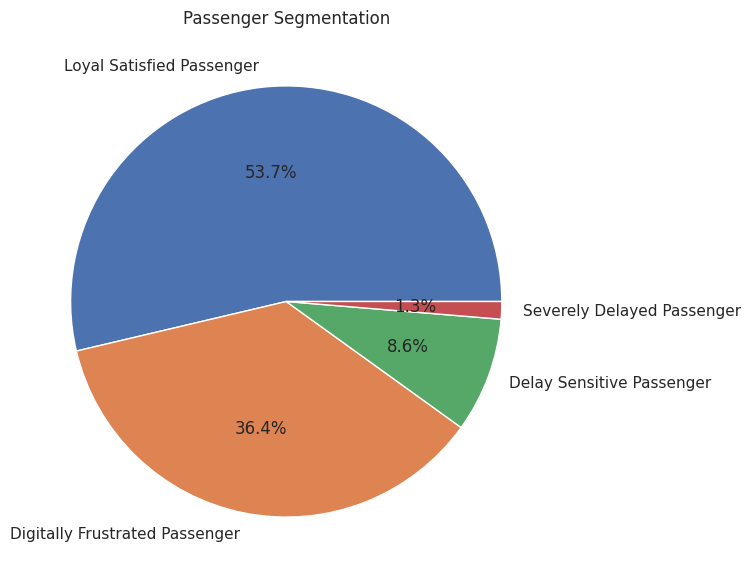

In [22]:
percent_cluster = (df_segm_pca['Segment'].value_counts(normalize=True)* 100)

plt.figure(figsize=(7,7))

plt.pie(
    percent_cluster.values,
    labels=percent_cluster.index,
    autopct='%1.1f%%'
)

plt.title('Passenger Segmentation')
plt.show()

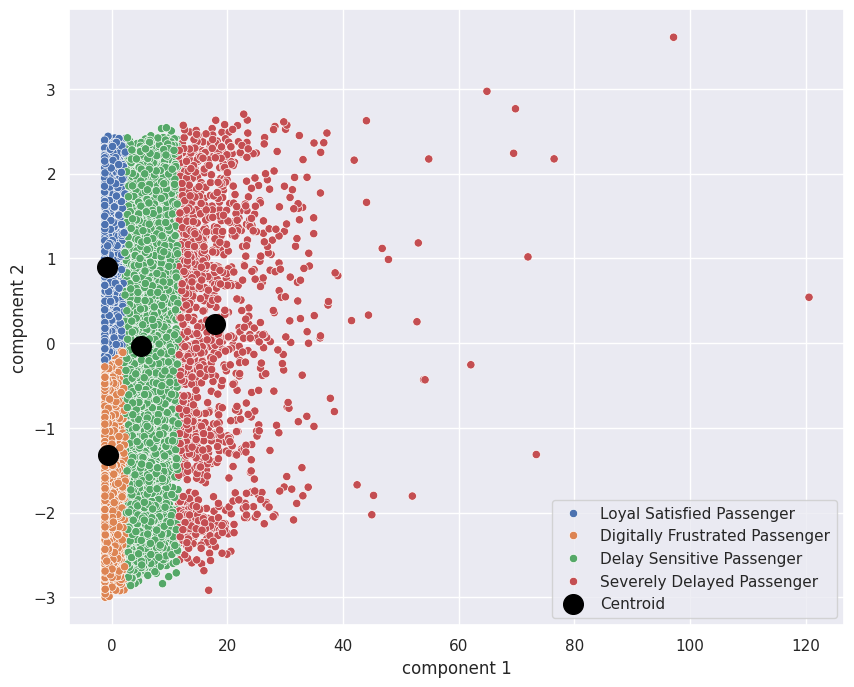

In [23]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x='component 1',
    y='component 2',
    hue='Segment',
    data=df_segm_pca
)

centers = kmeans_pca.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    color='black',
    s=200,
    label='Centroid'
)

plt.legend()
plt.show()

#Hierarchy

In [24]:
import pandas as pd

pca_sample = pd.DataFrame(pca_scores).sample(
    n=2500,
    random_state=42
)

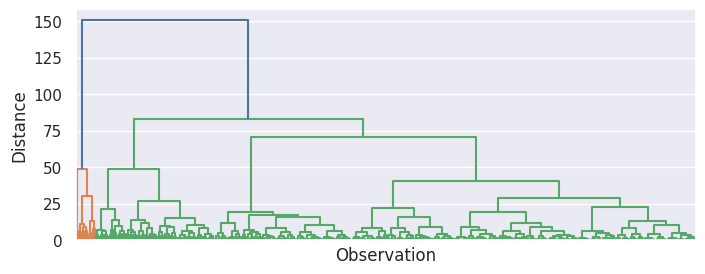

In [25]:
from scipy.cluster.hierarchy import linkage, dendrogram

h_cluster = linkage(pca_sample, method='ward')

plt.figure(figsize=(8,3))
plt.xlabel('Observation')
plt.ylabel('Distance')

dendrogram(
    h_cluster,
    show_leaf_counts=False,
    no_labels=True
)

plt.show()

In [26]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(
    n_clusters=4,
    metric='euclidean',
    linkage='ward'
)

model.fit(pca_sample)

AgglomerativeClustering(n_clusters=4)

In [27]:
df_hc = pca_sample.copy()

df_hc['hc PCA'] = model.labels_

df_hc.head()

,0,1,2,3,hc PCA
80638,-1.167062,-0.268515,-0.316063,0.870991,1
43398,0.067888,-1.675368,-0.454638,-0.869843,3
32751,1.488638,-0.691581,-1.286042,-0.115715,2
33571,-0.850237,-2.463235,-0.047381,-0.253511,3
71287,-1.135424,-1.572646,-0.060639,-0.733048,3


In [28]:
#cek distribusi data
pd.Series(model.labels_).value_counts()

,count
1,1388
3,551
2,481
0,80


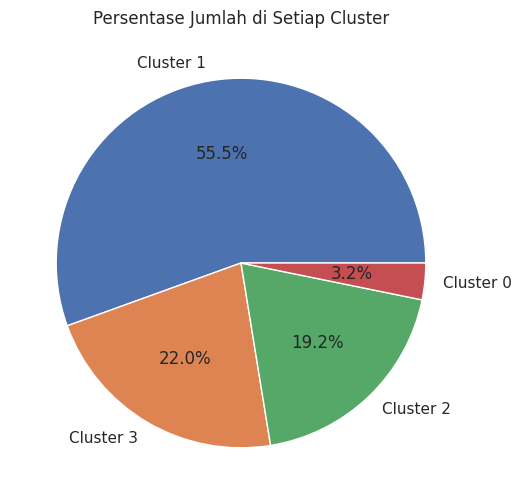

In [29]:
percent_clusters = (
    df_hc['hc PCA']
    .value_counts(normalize=True)
    * 100
)

plt.figure(figsize=(6,6))

plt.pie(
    percent_clusters.values,
    labels=[f'Cluster {i}' for i in percent_clusters.index],
    autopct='%1.1f%%'
)

plt.title('Persentase Jumlah di Setiap Cluster')
plt.show()

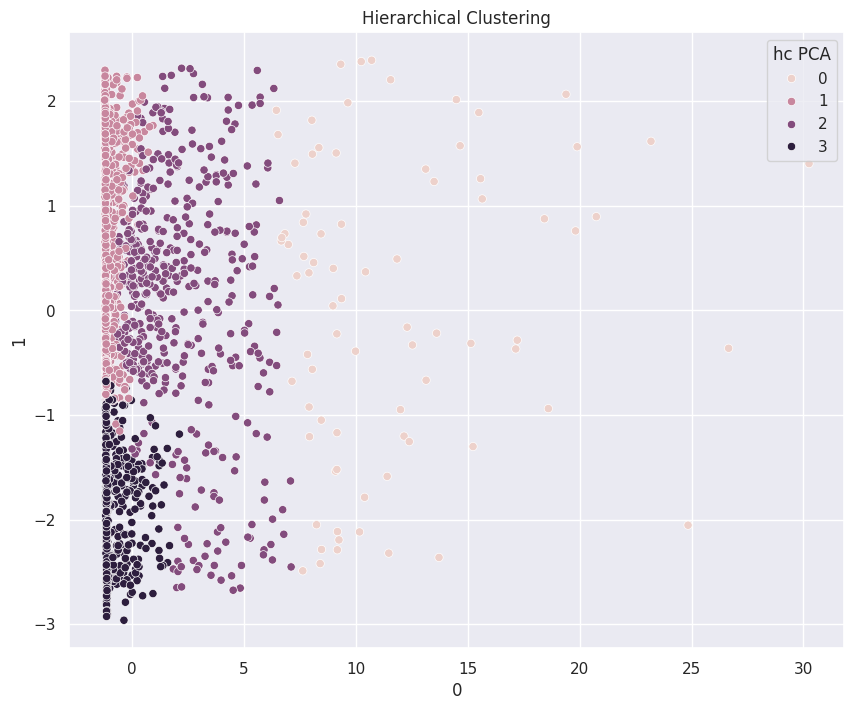

In [30]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df_hc,
    x=0,
    y=1,
    hue='hc PCA'
)

plt.title('Hierarchical Clustering')
plt.show()

#DBSCAN

In [31]:
dbscan_data = pca_sample

In [32]:
db = DBSCAN(
    eps=2,
    min_samples=5
)

labels = db.fit_predict(pca_sample)

pd.Series(labels).value_counts().sort_index()

,count
-1,15
0,2480
1,5


In [33]:
for eps in [1,2,3,4,5]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(pca_sample)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)

    print(f"eps={eps}, clusters={n_clusters}, noise={n_noise}")

eps=1, clusters=4, noise=120
eps=2, clusters=2, noise=15
eps=3, clusters=1, noise=3
eps=4, clusters=1, noise=3
eps=5, clusters=1, noise=2


In [34]:
db = DBSCAN(
    eps=1,
    min_samples=5
)

labels = db.fit_predict(pca_sample)

pd.Series(labels).value_counts().sort_index()

,count
-1,120
0,2357
1,13
2,5
3,5


In [35]:
df_dbscan = pca_sample.copy()

df_dbscan['DBSCAN'] = labels

df_dbscan.head()

,0,1,2,3,DBSCAN
80638,-1.167062,-0.268515,-0.316063,0.870991,0
43398,0.067888,-1.675368,-0.454638,-0.869843,0
32751,1.488638,-0.691581,-1.286042,-0.115715,0
33571,-0.850237,-2.463235,-0.047381,-0.253511,0
71287,-1.135424,-1.572646,-0.060639,-0.733048,0


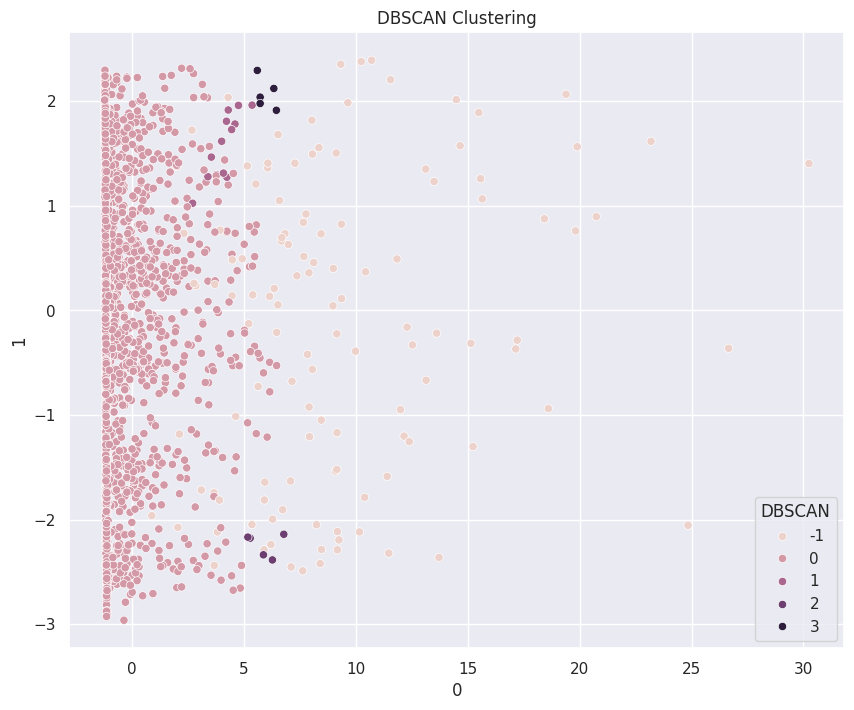

In [36]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    data=df_dbscan,
    x=0,
    y=1,
    hue='DBSCAN'
)

plt.title('DBSCAN Clustering')
plt.show()

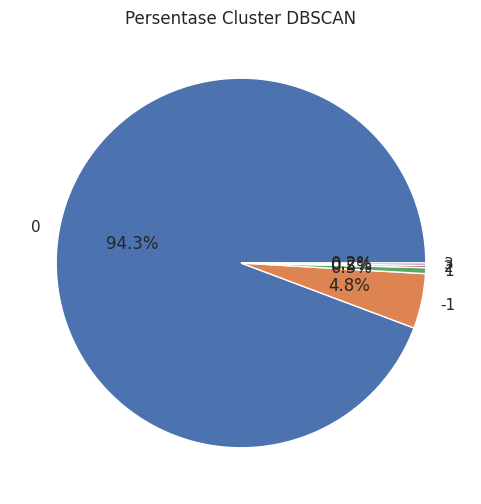

In [37]:
percent_cluster = (
    df_dbscan['DBSCAN']
    .value_counts(normalize=True)
    *100
)

plt.figure(figsize=(6,6))
plt.pie(
    percent_cluster.values,
    labels=percent_cluster.index,
    autopct='%1.1f%%'
)
plt.title('Persentase Cluster DBSCAN')
plt.show()

#Profiling

In [38]:
df_cluster = df_vif_clean.copy()

df_cluster['cluster'] = kmeans_pca.labels_

In [39]:
def highlight_max_min(s):
    is_max = s == s.max()
    is_min = s == s.min()

    return [
        'background-color:red' if v
        else 'background-color:lightgreen' if is_min[i]
        else ''
        for i, v in enumerate(is_max)
    ]

profil = (
    df_cluster
    .groupby('cluster')
    .mean(numeric_only=True)
    .round(2)
    .T
)

profil.style.apply(highlight_max_min, axis=1)

cluster,0,1,2,3
flight distance,1344.360000,1218.510000,969.720000,1147.210000
food and drink,3.340000,2.980000,3.020000,3.120000
on-board service,3.740000,3.170000,2.890000,3.270000
leg room service,3.620000,3.650000,2.950000,3.310000
checkin service,4.140000,3.280000,2.090000,3.230000
arrival delay in minutes,5.020000,248.460000,6.140000,81.830000
avg digital score,3.210000,2.980000,2.720000,2.930000
class,1.260000,1.000000,0.690000,0.990000
gender_Male,0.500000,0.500000,0.490000,0.490000
customer type_Loyal Customer,0.840000,0.810000,0.780000,0.810000


#Evaluasi Perbandingan

In [40]:
# KMeans sample
kmeans_sample = KMeans(
    n_clusters=4,
    random_state=42
)

kmeans_sample.fit(pca_sample)

KMeans(n_clusters=4, random_state=42)

In [41]:
hc_model = AgglomerativeClustering(
    n_clusters=4,
    metric='euclidean'
)

hc_model.fit(pca_sample)

AgglomerativeClustering(n_clusters=4)

In [42]:
db = DBSCAN(
    eps=1,
    min_samples=5
)

dbscan_labels = db.fit_predict(pca_sample)

In [43]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

def create_comparison_table(data, kmeans_model, hierarchical_model, dbscan_labels):

    # KMeans
    kmeans_silhouette = silhouette_score(data, kmeans_model.labels_)
    kmeans_ch = calinski_harabasz_score(data, kmeans_model.labels_)
    kmeans_db = davies_bouldin_score(data, kmeans_model.labels_)

    # Hierarchical
    hierarchical_silhouette = silhouette_score(data, hierarchical_model.labels_)
    hierarchical_ch = calinski_harabasz_score(data, hierarchical_model.labels_)
    hierarchical_db = davies_bouldin_score(data, hierarchical_model.labels_)

    # DBSCAN
    mask = dbscan_labels != -1

    dbscan_silhouette = silhouette_score(
        data[mask],
        dbscan_labels[mask]
    )

    dbscan_ch = calinski_harabasz_score(
        data[mask],
        dbscan_labels[mask]
    )

    dbscan_db = davies_bouldin_score(
        data[mask],
        dbscan_labels[mask]
    )

    comparison_table = pd.DataFrame({
        'Metric': [
            'Silhouette Score',
            'Calinski-Harabasz Index',
            'Davies-Bouldin Index'
        ],
        'KMeans': [
            kmeans_silhouette,
            kmeans_ch,
            kmeans_db
        ],
        'Hierarchical': [
            hierarchical_silhouette,
            hierarchical_ch,
            hierarchical_db
        ],
        'DBSCAN': [
            dbscan_silhouette,
            dbscan_ch,
            dbscan_db
        ]
    })

    return comparison_table

In [44]:
comparison_table = create_comparison_table(
    pca_sample,
    kmeans_sample,
    hc_model,
    dbscan_labels
)

comparison_table

,Metric,KMeans,Hierarchical,DBSCAN
0,Silhouette Score,0.253211,0.294309,0.459656
1,Calinski-Harabasz Index,1337.077318,1541.197774,56.853225
2,Davies-Bouldin Index,1.294718,1.044452,0.591178


Berdasarkan nilai Silhouette Score dan Davies-Bouldin Index, DBSCAN menunjukkan performa terbaik dibandingkan model lainnya. Namun, DBSCAN dan Hierarchical Clustering dijalankan menggunakan sampel data sebanyak 2.500 observasi karena keterbatasan komputasi, sehingga hasil evaluasi tidak dapat dibandingkan secara langsung dengan K-Means yang menggunakan jumlah data berbeda.
Oleh karena itu, model yang dipilih untuk analisis segmentasi adalah K-Means, karena mampu mengolah seluruh dataset secara lebih stabil dan menghasilkan segmentasi yang tetap memiliki kualitas clustering yang baik.